<a href="https://colab.research.google.com/github/anaghasurendran145-maker/mmmm/blob/main/customer_segmentation_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*CUSTOMER SEGMENTATION*

In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

In [2]:
df = pd.read_csv("/content/customer_segmentation.csv",encoding='latin1')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df = df.dropna(subset=['Income'])

**Age**

In [5]:
df['Age'] = 2026 - df['Year_Birth']

**Total Spending**

In [6]:
spending_cols = [col for col in df.columns if 'Mnt' in col]
df['Total_Spent'] = df[spending_cols].sum(axis=1)

**Total Children**

In [7]:
df['Children'] = df['Kidhome'] + df['Teenhome']

**Simplify Martial Status**

In [8]:
df['Living_With'] = df['Marital_Status'].replace({
    'Married': 'Partner', 'Together': 'Partner',
    'Absurd': 'Alone', 'Widow': 'Alone', 'YOLO': 'Alone',
    'Divorced': 'Alone', 'Single': 'Alone'
})

**Feature selection**

In [9]:
features = ['Income', 'Age', 'Total_Spent', 'Children', 'Recency', 'NumWebVisitsMonth']
X = df[features].copy()

In [10]:
le = LabelEncoder()
X['Living_With'] = le.fit_transform(df['Living_With'])

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Dimensionality Reduction**



In [12]:
pca = PCA(n_components=3)
pca_data = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3'])

**Elbow Method**

Determining optimal number of clusters...


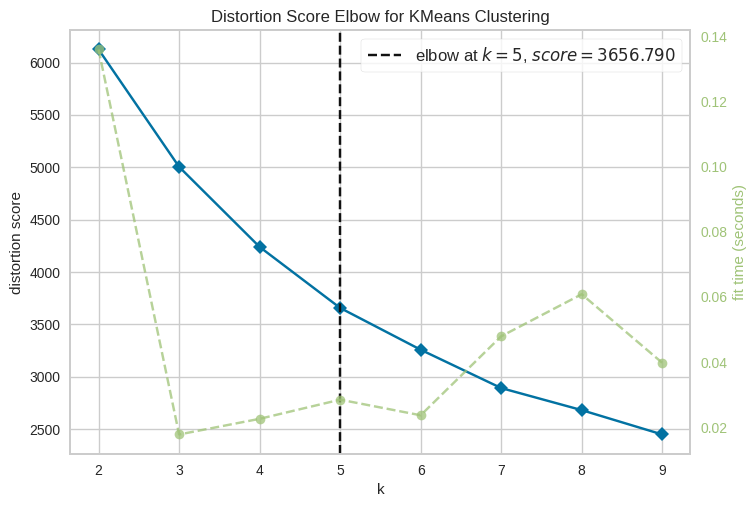

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [13]:
print("Determining optimal number of clusters...")
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,10))
visualizer.fit(pca_df)
k_best = visualizer.elbow_value_
visualizer.show()

**K-Means Clustering**

In [14]:
kmeans = KMeans(n_clusters=k_best, random_state=42)
df['Cluster'] = kmeans.fit_predict(pca_df)

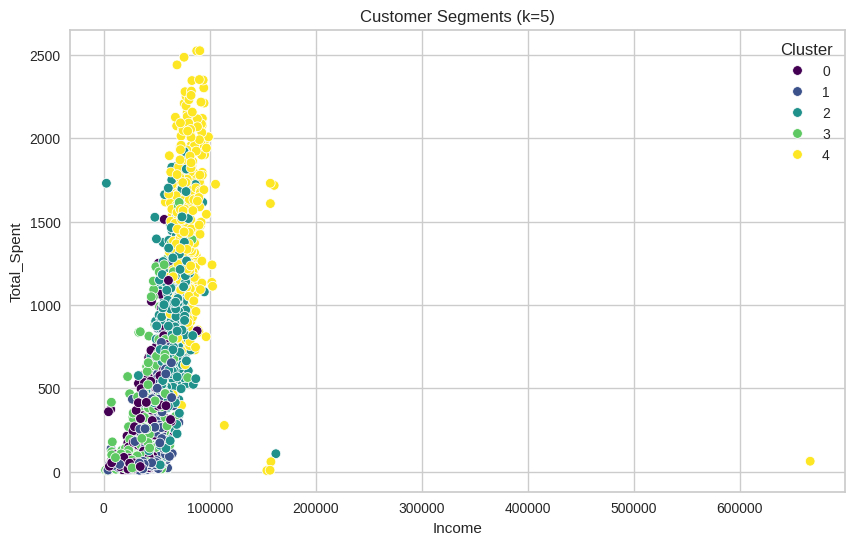

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='Total_Spent', hue='Cluster', palette='viridis')
plt.title(f'Customer Segments (k={k_best})')
plt.show()

**INSIGHTS**

**The Clusters we got:"**

1.Segment 1 & 3 (Orange/Red): These represent your "Middle Class" or "Average" shoppers.

2.Segment 0 (Blue): These appear to be your "Lower Value" or "New" customers.

3.Segment 2 (Green): These are your VIPs.